# Dataset Download

In [1]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/creditcardfraud


# Initial Exploration

Dataset shape: (284807, 31)

Data types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class   

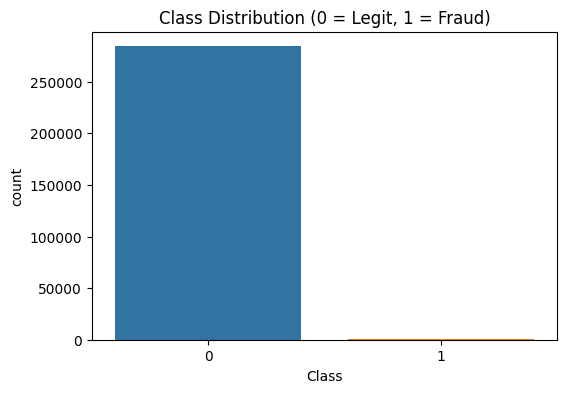

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


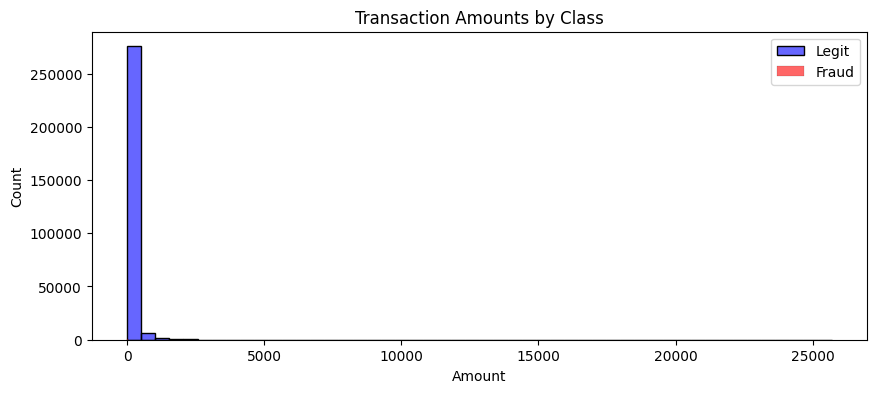

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dataset_path = "/kaggle/input/creditcardfraud/creditcard.csv"
df = pd.read_csv(dataset_path)

print("Dataset shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())

print("\nClass distribution:\n", df['Class'].value_counts())
print("\nPercentage distribution:\n", df['Class'].value_counts(normalize=True) * 100)

print("\nStatistical summary:\n", df.describe())
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='blue', label='Legit', alpha=0.6)
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', label='Fraud', alpha=0.6)
plt.title("Transaction Amounts by Class")
plt.legend()
plt.show()



/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


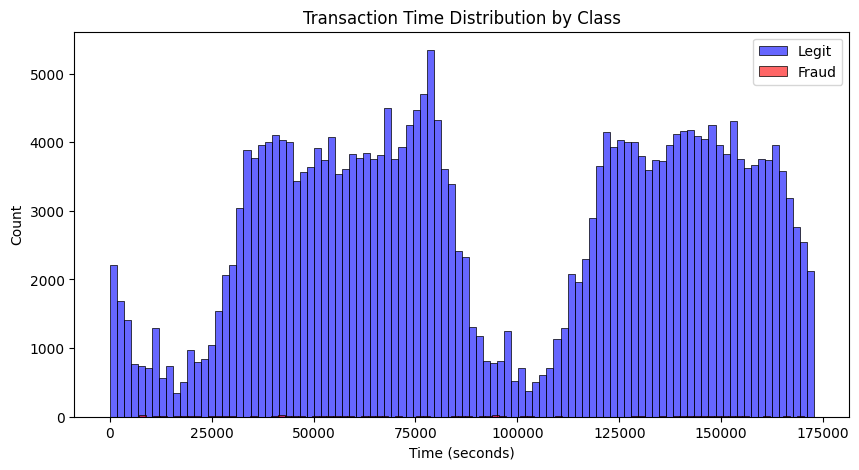

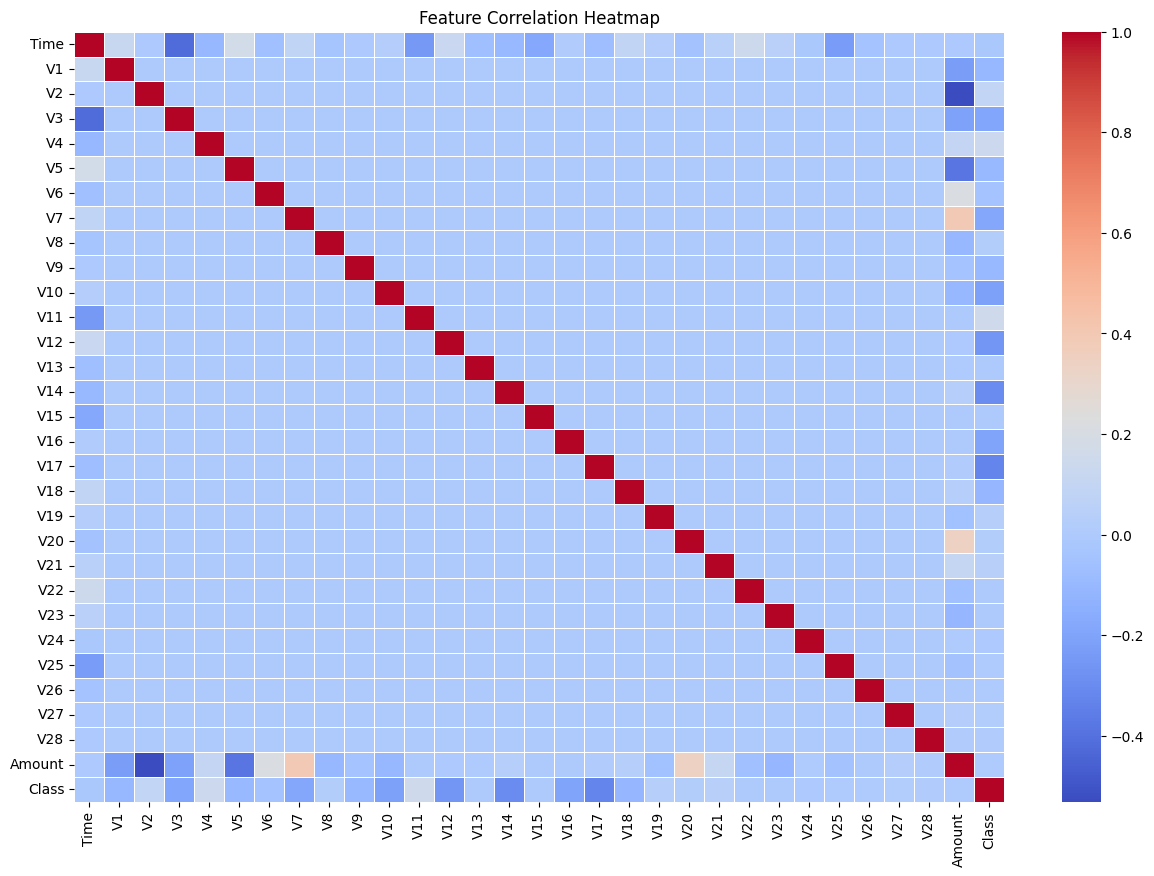

In [3]:
plt.figure(figsize=(10,5))
sns.histplot(df[df['Class'] == 0]['Time'], bins=100, color='blue', label='Legit', alpha=0.6)
sns.histplot(df[df['Class'] == 1]['Time'], bins=100, color='red', label='Fraud', alpha=0.6)
plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time (seconds)")
plt.legend()
plt.show()

plt.figure(figsize=(15,10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [4]:
corr_with_class = corr['Class'].sort_values(ascending=False)
print(corr_with_class.head(10))

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64


# Handling Class Imbalance using Oversampling

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

dataset_path = "/kaggle/input/creditcardfraud/creditcard.csv"
df = pd.read_csv(dataset_path)

X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_majority = X_train[y_train == 0]
y_train_majority = y_train[y_train == 0]

X_train_minority = X_train[y_train == 1]
y_train_minority = y_train[y_train == 1]

n_repeat = len(y_train_majority) // len(y_train_minority)  # how many times to repeat
X_train_minority_oversampled = pd.concat([X_train_minority]*n_repeat, ignore_index=True)
y_train_minority_oversampled = pd.concat([y_train_minority]*n_repeat, ignore_index=True)

X_train_balanced = pd.concat([X_train_majority, X_train_minority_oversampled], ignore_index=True)
y_train_balanced = pd.concat([y_train_majority, y_train_minority_oversampled], ignore_index=True)

print("Balanced training set class counts:")
print(y_train_balanced.value_counts())


Balanced training set class counts:
Class
0    227451
1    227338
Name: count, dtype: int64


# Initial XGBoost Model with only unsampled data

Classification Report:

              precision    recall  f1-score   support

           0     0.9998    0.9985    0.9991     56864
           1     0.5000    0.8673    0.6343        98

    accuracy                         0.9983     56962
   macro avg     0.7499    0.9329    0.8167     56962
weighted avg     0.9989    0.9983    0.9985     56962



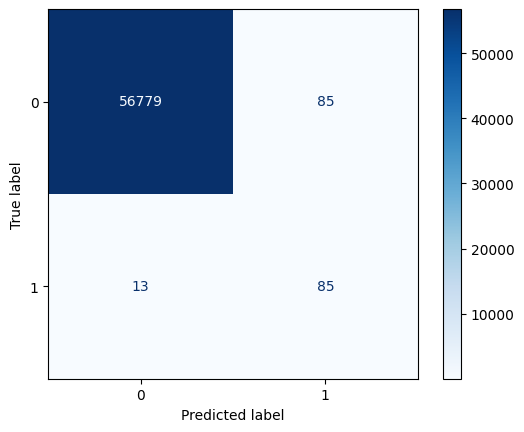

In [6]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


dtrain = xgb.DMatrix(X_train_balanced, label=y_train_balanced)
dtest = xgb.DMatrix(X_test, label=y_test)


params = {
    'objective': 'binary:logistic', 
    'eval_metric': 'auc',             
    'max_depth': 5,
    'eta': 0.1,
    'seed': 42
}


bst = xgb.train(params, dtrain, num_boost_round=100)

y_pred_prob = bst.predict(dtest)

y_pred = (y_pred_prob > 0.5).astype(int)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap='Blues')


# Improved XGBoost Model with Feature Engineering

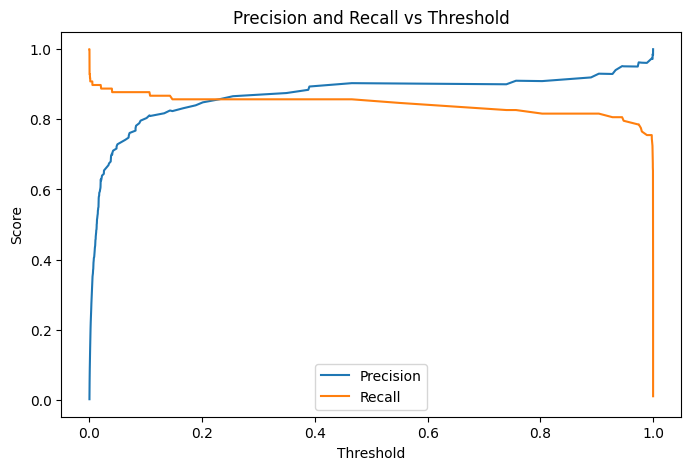


Classification Report at threshold 0.3:

              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998     56864
           1     0.8750    0.8571    0.8660        98

    accuracy                         0.9995     56962
   macro avg     0.9374    0.9285    0.9329     56962
weighted avg     0.9995    0.9995    0.9995     56962



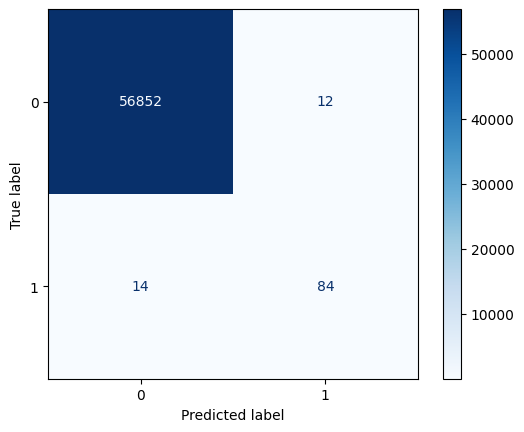

In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_balanced[['Time', 'Amount']] = scaler.fit_transform(X_train_balanced[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])


for df in [X_train_balanced, X_test]:
    df['Hour_of_day'] = (df['Time'] // 3600) % 24
    df['Log_Amount'] = np.log1p(df['Amount'])

dtrain = xgb.DMatrix(X_train_balanced, label=y_train_balanced)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 6,
    'eta': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    
    'seed': 42
}

bst = xgb.train(params, dtrain, num_boost_round=500)


y_pred_prob = bst.predict(dtest)

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.show()

optimal_threshold = 0.3
y_pred_optimal = (y_pred_prob > optimal_threshold).astype(int)

print("\nClassification Report at threshold 0.3:\n")
print(classification_report(y_test, y_pred_optimal, digits=4))

cm = confusion_matrix(y_test, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap='Blues')


AUC-ROC Score: 0.9747


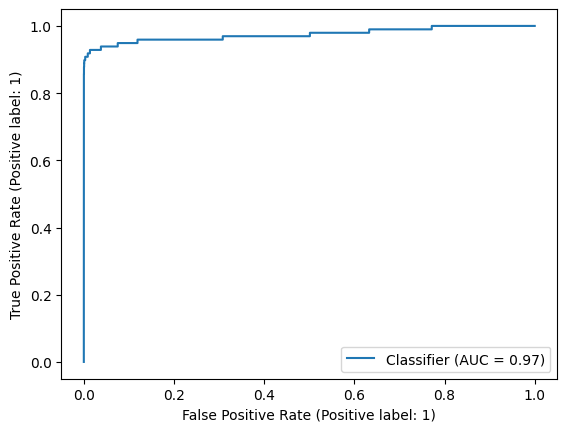

In [8]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC Score: {roc_auc:.4f}")
RocCurveDisplay.from_predictions(y_test, y_pred_prob)
plt.show()